# NC-Subtract vs Original: Classification Performance Comparison

Compares classification accuracy between **original** curves (`POC_DDM_multi`) and the
**NC-subtract** preprocessing variant (`POC_DDM_multi_nc_subtract`, negative-control subtracted),
across datasets, models, outlier filters, and curve types.

Datasets covered: `norm_temp_04`, `norm_temp_read_06`, `norm_temp_read_07`, `norm_temp_ready_08`,
`lambda_test_manifold_01`.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patheffects
from pathlib import Path

In [2]:
import os

try:
    # VS Code injects '__vsc_ipynb_file__' into the globals automatically
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        notebook_dir = os.path.dirname(notebook_path)
        os.chdir(notebook_dir)
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config
%matplotlib inline

Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main

[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## 1. Configuration
Dataset/model/filter/curve-type universe + folder paths. All driven from `config.py` where possible.

In [3]:
TARGET_FOLDERS = [
    "D20260608_E00_C00_F4500KHz_U_norm_temp_04",
    "D20260609_E00_C00_F4500KHz_U_norm_temp_read_06",
    "D20260609_E00_C00_F4500KHz_U_norm_temp_read_07",
    "D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08",
    "D20260611_E00_C00_F4500KHz_U_lambda_test_manifold_01",
]

import os

try:
    # VS Code injects '__vsc_ipynb_file__' into the globals automatically
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        notebook_dir = os.path.dirname(notebook_path)
        os.chdir(notebook_dir)
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config
%matplotlib inline
def short_name(folder_name):
    """D20260608_E00_C00_F4500KHz_U_norm_temp_04 -> norm_temp_04"""
    return folder_name.split("_U_", 1)[1]

DATASET_NAMES = [short_name(f) for f in TARGET_FOLDERS]

PREPROCESSING_FOLDERS = {
    "original": config.MULTI_EXP_FOLDER,
    "nc_subtract": config.MULTI_EXP_FOLDER + "_nc_subtract",
}
PREPROCESSING_KEYS = list(PREPROCESSING_FOLDERS.keys())

# CLI curve_type value -> top-level key inside classification_performances_nonorm.joblib
CURVE_TYPE_JOBLIB_KEYS = {
    "ori_curves": "Ori Curves",
    "ori_curves_avg": "Ori Curves Avg",
}
CURVE_TYPES = list(CURVE_TYPE_JOBLIB_KEYS.keys())

# MODELS = ["cnn", "gru", "transformer", "cnn_lf", "gru_lf", "trans_lf", "cnn_gru_dual", "cnn_trans_dual"]
MODELS = ["cnn", "gru", "transformer", "cnn_gru_dual", "cnn_trans_dual"]
OUTLIER_FILTERS = [None, "lstm_ae_glb_ds1_label_elbow", "spatial_knn_label_elbow", "spatial_grid_label_elbow"]

print(f"Datasets: {DATASET_NAMES}")
print(f"Preprocessing: {PREPROCESSING_KEYS}")
print(f"Curve types: {CURVE_TYPES}")
print(f"Models: {MODELS}")
print(f"Outlier filters: {OUTLIER_FILTERS}")

Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Datasets: ['norm_temp_04', 'norm_temp_read_06', 'norm_temp_read_07', 'norm_temp_ready_08', 'lambda_test_manifold_01']
Preprocessing: ['original', 'nc_subtract']
Curve types: ['ori_curves', 'ori_curves_avg']
Models: ['cnn', 'gru', 'transformer', 'cnn_gru_dual', 'cnn_trans_dual']
Outlier filters: [None, 'lstm_ae_glb_ds1_label_elbow', 'spatial_knn_label_elbow', 'spatial_grid_label_elbow']


## 2. Load results into a tidy long-format DataFrame
One row per (dataset, preprocessing, curve_type, outlier_filter, model) combination -- every plot below just filters/pivots this single DataFrame.

In [4]:
def _merge_nc_label(label):
    """Collapses per-target NC labels (e.g. 'NC-S', 'NC-Conc-01') into a single 'NC' class."""
    return "NC" if str(label).startswith("NC-") else label


def _encoded_classes_for_folder(folder):
    """Reconstructs the LabelEncoder class order used at training time for `folder`.

    LabelEncoder.fit_transform sorts unique labels alphabetically, and every historical
    run (pre label-mapping fix) built Y_well via config.LABEL_MAPPINGS[folder] regardless
    of preprocessing variant -- so this recreates the exact int<->label correspondence
    baked into the saved y_trues_/predictions, for both 'original' and 'nc_subtract' runs.
    """
    mapping = config.LABEL_MAPPINGS[folder]
    return np.array(sorted(set(mapping.values())))


def compute_accuracy(performances, model_key, merge_nc_classes=False, folder=None):
    """Mean/std accuracy across folds for one model, from a single outlier-filter result dict.

    merge_nc_classes: if True, treats all per-target NC classes (e.g. 'NC-S'/'NC-C',
    'NC-Conc-01'/'NC-Conc-02') as a single 'NC' class before scoring -- lets you recompute
    accuracy for runs trained with the old per-target NC mapping (the nc_subtract bug),
    without retraining. Requires `folder` (the experiment folder name) when True.
    """
    pred_key, _, _ = config.MODEL_KEY_MAP[model_key]
    if pred_key not in performances:
        return None

    if merge_nc_classes:
        classes = _encoded_classes_for_folder(folder)
        merged_lookup = np.array([_merge_nc_label(c) for c in classes])
        accs = [
            (merged_lookup[np.asarray(y_pred)] == merged_lookup[np.asarray(y_true)]).mean()
            for y_true, y_pred in zip(performances["y_trues_"], performances[pred_key])
        ]
    else:
        accs = [
            (np.asarray(y_pred) == np.asarray(y_true)).mean()
            for y_true, y_pred in zip(performances["y_trues_"], performances[pred_key])
        ]
    return float(np.mean(accs)), float(np.std(accs))


def load_results_long_df(merge_nc_classes=False):
    """merge_nc_classes: passed straight through to compute_accuracy -- set True to
    recalculate accuracy with per-target NC classes merged into one 'NC' class (see
    compute_accuracy docstring). Applies to every row, including 'original' preprocessing,
    so filter to preprocessing == 'nc_subtract' afterwards if you only want the corrected
    nc_subtract numbers and want to leave 'original' as-is."""
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        for prep_key, base_folder in PREPROCESSING_FOLDERS.items():
            result_path = Path(base_folder) / folder / "classification_performances_old.joblib"
            if not result_path.exists():
                result_path = Path(base_folder) / folder / config.TRAINING_RESULT_PATH
                if not result_path.exists():
                    result_path = Path(base_folder) / folder / "classification_performances_nonorm.joblib"
                    if not result_path.exists():
                        print(f"[WARN] missing results file: {result_path}")
                        continue
            print(result_path)
            data = joblib.load(result_path)
            for curve_type, joblib_key in CURVE_TYPE_JOBLIB_KEYS.items():
                native = data.get(joblib_key, {}).get("Native", {})
                for outlier_filter in OUTLIER_FILTERS:
                    performances = native.get(outlier_filter)
                    if performances is None:
                        continue
                    for model in MODELS:
                        result = compute_accuracy(performances, model,
                                                   merge_nc_classes=merge_nc_classes, folder=folder)
                        if result is None:
                            continue
                        mean_acc, std_acc = result
                        rows.append({
                            "dataset": dataset,
                            "preprocessing": prep_key,
                            "curve_type": curve_type,
                            "outlier_filter": outlier_filter,
                            "model": model,
                            "accuracy_mean": mean_acc * 100,
                            "accuracy_std": std_acc * 100,
                        })
    return pd.DataFrame(rows)


results_df = load_results_long_df(merge_nc_classes=True)
print(f"\nLoaded {len(results_df)} rows.")
results_df.head()

/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi/D20260608_E00_C00_F4500KHz_U_norm_temp_04/classification_performances_nonorm.joblib
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi_nc_subtract/D20260608_E00_C00_F4500KHz_U_norm_temp_04/classification_performances_nonorm.joblib
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi/D20260609_E00_C00_F4500KHz_U_norm_temp_read_06/classification_performances_nonorm.joblib
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi_nc_subtract/D20260609_E00_C00_F4500KHz_U_norm_temp_read_06/classification_performances_nonorm.joblib
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi/D20260609_E00_C00_F4500KHz_U_norm_temp_read_07/classification_performances_nonorm.joblib
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi_nc_subtract/D20260609_E00_C00_F4500KHz_U_norm_temp_read_07/classification_performances_nonorm.joblib
/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi/D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08/classification_performances_

,dataset,preprocessing,curve_type,outlier_filter,model,accuracy_mean,accuracy_std
0,norm_temp_04,nc_subtract,ori_curves,None,cnn,99.51720,0.0
1,norm_temp_04,nc_subtract,ori_curves,None,gru,100.00000,0.0
2,norm_temp_04,nc_subtract,ori_curves,None,transformer,99.93965,0.0
3,norm_temp_04,nc_subtract,ori_curves,None,cnn_gru_dual,99.93965,0.0
4,norm_temp_04,nc_subtract,ori_curves,None,cnn_trans_dual,100.00000,0.0


## 3. Data completeness check

Some (dataset, preprocessing, curve_type) combinations are missing outlier-filter/model
entries -- usually because that training run is still in progress or was never
force-rerun to completion. Plots below show `N/A` for any missing bar; this cell tells you
exactly which combos to distrust.

In [5]:
_expected_per_combo = len(OUTLIER_FILTERS) * len(MODELS)
completeness = (
    results_df.groupby(["dataset", "preprocessing", "curve_type"])
    .size()
    .reset_index(name="n_rows")
)
completeness["expected"] = _expected_per_combo
completeness["complete"] = completeness["n_rows"] == completeness["expected"]

incomplete = completeness[~completeness["complete"]]
if incomplete.empty:
    print("All (dataset, preprocessing, curve_type) combinations are fully populated.")
else:
    print("[!] Incomplete combinations (fewer than the expected "
          f"{_expected_per_combo} filter x model rows):")
    display(incomplete.drop(columns="complete"))

[!] Incomplete combinations (fewer than the expected 20 filter x model rows):


,dataset,preprocessing,curve_type,n_rows,expected
5,norm_temp_04,nc_subtract,ori_curves_avg,13,20
7,norm_temp_read_06,nc_subtract,ori_curves_avg,11,20
9,norm_temp_read_07,nc_subtract,ori_curves_avg,11,20
10,norm_temp_ready_08,nc_subtract,ori_curves,4,20
11,norm_temp_ready_08,nc_subtract,ori_curves_avg,4,20


## 4. Colour & label maps (sourced from `config.py`)

In [6]:
# Models: keep CNN/GRU/Transformer tied to their canonical config.MODEL_COLORS entry;
# late-fusion / dual variants fall back to the next unused colour in config.VIZ_PALETTE.
MODEL_FIXED_COLORS = {
    "cnn": config.MODEL_COLORS["CNN"],
    "gru": config.MODEL_COLORS["GRU"],
    "transformer": config.MODEL_COLORS["Transformer"],
}
MODEL_COLOR_MAP = config.get_palette(MODELS, MODEL_FIXED_COLORS)
MODEL_LABEL_MAP = config.MODEL_PRINT_MAP

# Outlier filters already have a dedicated, stable palette in config.
FILTER_COLOR_MAP = config.FILTER_COLORS
FILTER_LABEL_MAP = config.FILTER_PRINT_MAP

# Curve types: "Ori Curves" keeps its config.CURVE_COLORS entry; the avg variant gets
# the next palette colour.
CURVE_COLOR_MAP = config.get_palette(CURVE_TYPES, {"ori_curves": config.CURVE_COLORS["Ori Curves"]})
CURVE_LABEL_MAP = config.CURVE_PRINT_MAP

# Preprocessing has no existing config entry; pull two colours straight from VIZ_PALETTE.
PREP_COLOR_MAP = config.get_palette(PREPROCESSING_KEYS)
PREP_LABEL_MAP = {"original": "Original", "nc_subtract": "NC-Subtract"}

_LABEL_MAPS = {
    "model": MODEL_LABEL_MAP,
    "outlier_filter": FILTER_LABEL_MAP,
    "curve_type": CURVE_LABEL_MAP,
    "preprocessing": PREP_LABEL_MAP,
}

## 5. Core plotting engine

One grouped-bar-chart function reused by all four required comparisons:
- x-axis = dataset (short name)
- hue = whatever dimension is being compared
- y-axis (accuracy %) starts at `floor(min_value / 10) * 10 - 10`, capped at 0, and always
  ends at 100 (e.g. lowest value 92% -> axis starts at 80%; lowest 75% -> starts at 60%)
- bar value labels are drawn inside each bar (white-outlined text) so they never collide
  with the title regardless of how close to 100% the bars are
- missing combinations are marked `N/A` instead of silently showing a zero-height bar

In [7]:
_TEXT_OUTLINE = [patheffects.withStroke(linewidth=2.5, foreground="white")]


def _eq(series, value):
    """`series == value` is always False when value is None (pandas quirk) -- use this
    instead whenever a column being compared can hold None (currently: outlier_filter)."""
    return series.isna() if value is None else series == value


def _accuracy_ylim(min_value):
    if pd.isna(min_value):
        return 0, 100
    tens = (min_value // 10) * 10
    return max(0, tens - 10), 100


def fixed_params_str(**kwargs):
    return " | ".join(f"{k}={_LABEL_MAPS.get(k, {}).get(v, str(v))}" for k, v in kwargs.items())


def grouped_bar_chart_generic(sub_df, x_col, x_order, hue_col, hue_order, color_map, label_map,
                               title, x_label=None, x_tick_label_map=None, figsize=None):
    """Generic grouped bar chart: x=x_col categories, sub-bars=hue_col categories, y=accuracy_mean."""
    x_tick_label_map = x_tick_label_map or {}
    n_groups = len(hue_order)
    bar_width = 0.8 / n_groups
    x = np.arange(len(x_order))
    fig, ax = plt.subplots(figsize=figsize or (max(11, len(x_order) * 2.4 + 2), 6.5))

    all_vals = []
    for i, key in enumerate(hue_order):
        means, stds = [], []
        for xv in x_order:
            row = sub_df[_eq(sub_df[x_col], xv) & _eq(sub_df[hue_col], key)]
            means.append(row["accuracy_mean"].iloc[0] if not row.empty else np.nan)
            stds.append(row["accuracy_std"].iloc[0] if not row.empty else 0)
        means_arr, stds_arr = np.array(means), np.array(stds)
        all_vals.extend(means_arr[~np.isnan(means_arr)].tolist())

        offset = (i - n_groups / 2 + 0.5) * bar_width
        ax.bar(x + offset, np.nan_to_num(means_arr, nan=0.0), width=bar_width,
               yerr=stds_arr, capsize=3, label=label_map.get(key, str(key)),
               color=color_map.get(key, "#cccccc"), edgecolor="black", linewidth=1,
               alpha=0.9, zorder=3)

        for xi, m, s in zip(x + offset, means_arr, stds_arr):
            if np.isnan(m):
                continue
            txt = f"{m:.1f}%" if s == 0 else f"{m:.1f}±{s:.1f}%"
            ax.text(xi, m - 0.5, txt, ha="center", va="top", fontsize=8, fontweight="bold",
                     rotation=90, color="black", path_effects=_TEXT_OUTLINE, zorder=4)

    ymin, ymax = _accuracy_ylim(min(all_vals) if all_vals else np.nan)

    # Mark missing combinations inside the visible axis range (not above it).
    for i, key in enumerate(hue_order):
        offset = (i - n_groups / 2 + 0.5) * bar_width
        for j, xv in enumerate(x_order):
            row = sub_df[_eq(sub_df[x_col], xv) & _eq(sub_df[hue_col], key)]
            if row.empty:
                ax.text(j + offset, ymin + (ymax - ymin) * 0.02, "N/A", ha="center",
                         va="bottom", fontsize=7, color="#999999", rotation=90, style="italic")

    ax.set_ylim(ymin, ymax)
    ax.set_xticks(x)
    ax.set_xticklabels([x_tick_label_map.get(v, str(v)) for v in x_order],
                        fontsize=11, fontweight="bold", rotation=15, ha="right")
    ax.set_ylabel("Accuracy (%)", fontsize=12, fontweight="bold")
    ax.set_xlabel(x_label or x_col.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10, framealpha=0.9)
    fig.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


def grouped_bar_chart(sub_df, hue_col, hue_order, color_map, label_map, title,
                       dataset_order=None, figsize=None):
    """x=dataset, sub-bars=hue_col categories, y=accuracy_mean."""
    grouped_bar_chart_generic(sub_df, "dataset", dataset_order or DATASET_NAMES, hue_col, hue_order,
                               color_map, label_map, title, x_label="Dataset", figsize=figsize)

## 6. Preprocessing comparison: Original vs NC-Subtract

Sub-bars = `original` vs `nc_subtract`, for a fixed model / outlier filter / curve type
(all changeable via function arguments).

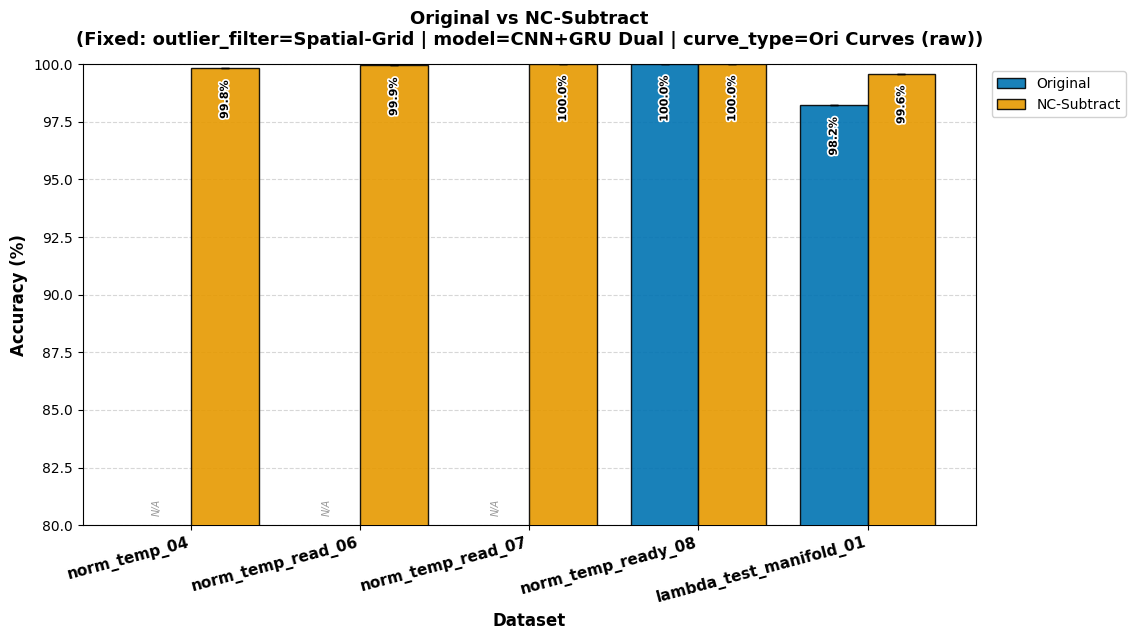

In [8]:
def plot_preprocessing_comparison(df, outlier_filter="spatial_grid_label_elbow",
                                    model="cnn_gru_dual", curve_type="ori_curves"):
    sub = df[_eq(df.outlier_filter, outlier_filter) & _eq(df.model, model) & _eq(df.curve_type, curve_type)]
    fixed = fixed_params_str(outlier_filter=outlier_filter, model=model, curve_type=curve_type)
    grouped_bar_chart(sub, "preprocessing", PREPROCESSING_KEYS, PREP_COLOR_MAP, PREP_LABEL_MAP,
                       title=f"Original vs NC-Subtract\n(Fixed: {fixed})")


plot_preprocessing_comparison(results_df)

## 7. Model comparison

Sub-bars = all 8 models, for a fixed outlier filter / preprocessing / curve type.

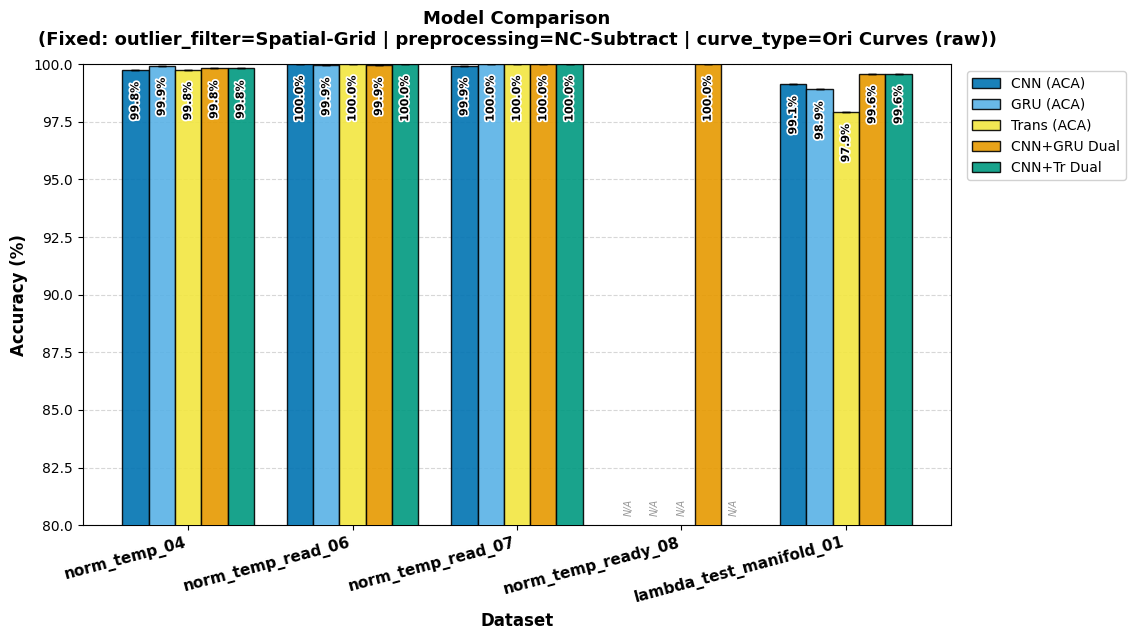

In [9]:
def plot_model_comparison(df, outlier_filter="spatial_grid_label_elbow",
                            preprocessing="nc_subtract", curve_type="ori_curves"):
    sub = df[_eq(df.outlier_filter, outlier_filter) & _eq(df.preprocessing, preprocessing) & _eq(df.curve_type, curve_type)]
    fixed = fixed_params_str(outlier_filter=outlier_filter, preprocessing=preprocessing, curve_type=curve_type)
    grouped_bar_chart(sub, "model", MODELS, MODEL_COLOR_MAP, MODEL_LABEL_MAP,
                       title=f"Model Comparison\n(Fixed: {fixed})")


plot_model_comparison(results_df)

## 8. Outlier filter comparison

Sub-bars = all 4 outlier filters, for a fixed model / preprocessing / curve type.

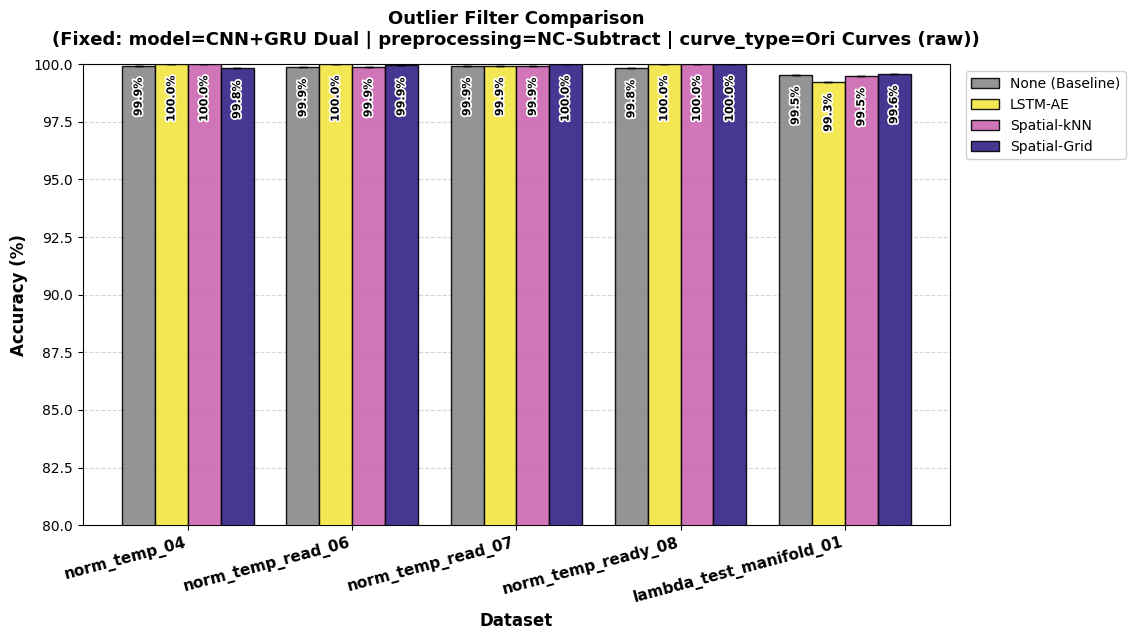

In [10]:
def plot_outlier_filter_comparison(df, model="cnn_gru_dual", preprocessing="nc_subtract",
                                     curve_type="ori_curves"):
    sub = df[_eq(df.model, model) & _eq(df.preprocessing, preprocessing) & _eq(df.curve_type, curve_type)]
    fixed = fixed_params_str(model=model, preprocessing=preprocessing, curve_type=curve_type)
    grouped_bar_chart(sub, "outlier_filter", OUTLIER_FILTERS, FILTER_COLOR_MAP, FILTER_LABEL_MAP,
                       title=f"Outlier Filter Comparison\n(Fixed: {fixed})")


plot_outlier_filter_comparison(results_df)

## 9. Curve type comparison

Sub-bars = `ori_curves` vs `ori_curves_avg`, for a fixed model / preprocessing / outlier filter.

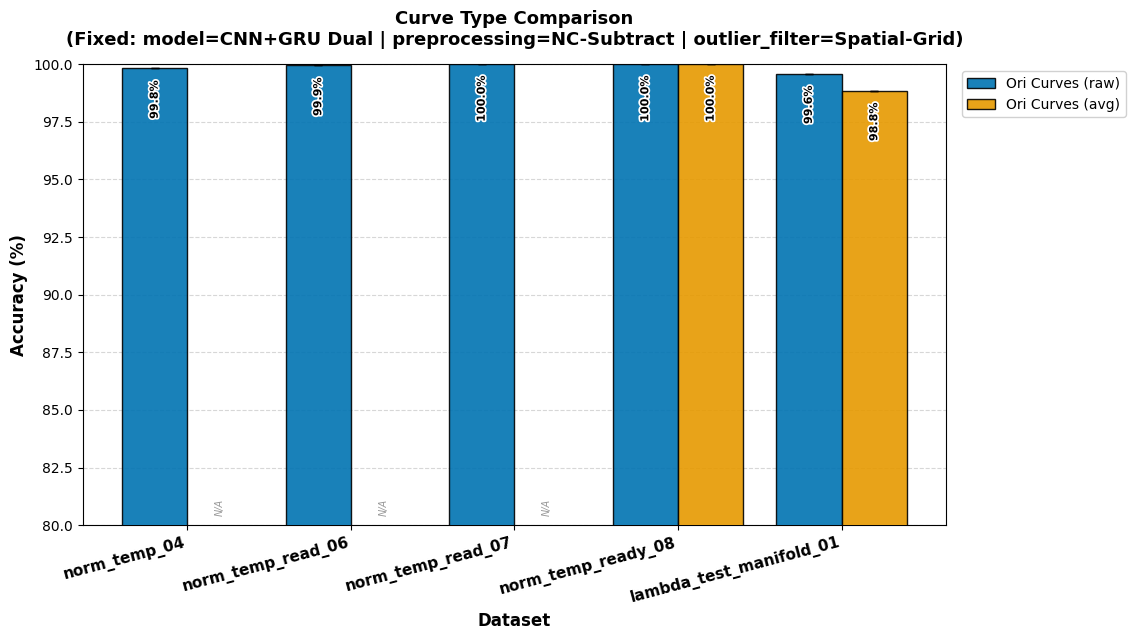

In [11]:
def plot_curve_type_comparison(df, model="cnn_gru_dual", preprocessing="nc_subtract",
                                 outlier_filter="spatial_grid_label_elbow"):
    sub = df[_eq(df.model, model) & _eq(df.preprocessing, preprocessing) & _eq(df.outlier_filter, outlier_filter)]
    fixed = fixed_params_str(model=model, preprocessing=preprocessing, outlier_filter=outlier_filter)
    grouped_bar_chart(sub, "curve_type", CURVE_TYPES, CURVE_COLOR_MAP, CURVE_LABEL_MAP,
                       title=f"Curve Type Comparison\n(Fixed: {fixed})")


plot_curve_type_comparison(results_df)

## 10. Bonus insight: overall model ranking

Averages each model's accuracy across all 5 datasets (for a fixed preprocessing / curve
type / outlier filter) -- a quick "which architecture wins overall" view, with the number
of datasets it was actually evaluated on (`n=`) shown alongside, since some models have
fewer valid datasets due to incomplete results (see Section 3).

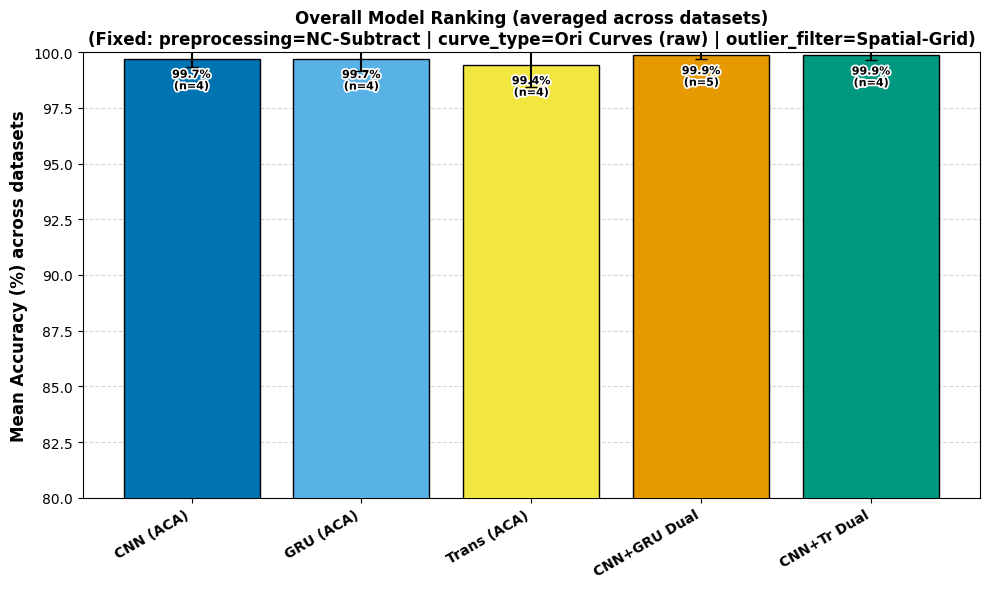

In [12]:
def plot_overall_model_ranking(df, preprocessing="nc_subtract", curve_type="ori_curves",
                                 outlier_filter="spatial_grid_label_elbow"):
    sub = df[_eq(df.preprocessing, preprocessing) & _eq(df.curve_type, curve_type) & _eq(df.outlier_filter, outlier_filter)]
    agg = sub.groupby("model")["accuracy_mean"].agg(["mean", "std", "count"]).reindex(MODELS)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [MODEL_COLOR_MAP[m] for m in agg.index]
    ax.bar(range(len(agg)), agg["mean"].fillna(0), yerr=agg["std"].fillna(0), capsize=4,
           color=colors, edgecolor="black", zorder=3)

    for i, (m, c) in enumerate(zip(agg["mean"], agg["count"])):
        if not np.isnan(m):
            ax.text(i, m - 0.5, f"{m:.1f}%\n(n={c})", ha="center", va="top", fontsize=8,
                     fontweight="bold", path_effects=_TEXT_OUTLINE)

    valid = agg["mean"].dropna()
    ymin, ymax = _accuracy_ylim(valid.min() if not valid.empty else np.nan)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels([MODEL_LABEL_MAP.get(m, m) for m in agg.index], rotation=30, ha="right", fontweight="bold")
    ax.set_ylabel("Mean Accuracy (%) across datasets", fontsize=12, fontweight="bold")
    fixed = fixed_params_str(preprocessing=preprocessing, curve_type=curve_type, outlier_filter=outlier_filter)
    ax.set_title(f"Overall Model Ranking (averaged across datasets)\n(Fixed: {fixed})", fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    fig.tight_layout()
    plt.show()


plot_overall_model_ranking(results_df)

## 11. Bonus insight: dataset x model accuracy heatmap

A single at-a-glance matrix for a fixed preprocessing / curve type / outlier filter.

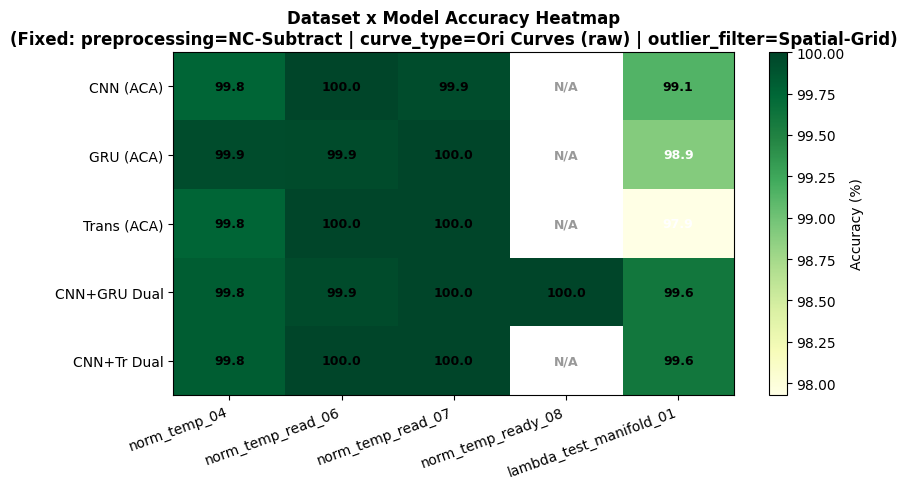

In [13]:
def plot_dataset_model_heatmap(df, preprocessing="nc_subtract", curve_type="ori_curves",
                                 outlier_filter="spatial_grid_label_elbow"):
    sub = df[_eq(df.preprocessing, preprocessing) & _eq(df.curve_type, curve_type) & _eq(df.outlier_filter, outlier_filter)]
    pivot = sub.pivot(index="model", columns="dataset", values="accuracy_mean").reindex(index=MODELS, columns=DATASET_NAMES)

    fig, ax = plt.subplots(figsize=(max(8, len(DATASET_NAMES) * 1.7), max(5, len(MODELS) * 0.65)))
    values = pivot.values.astype(float)
    finite = values[~np.isnan(values)]
    vmin = finite.min() if finite.size else 0
    im = ax.imshow(values, cmap="YlGn", vmin=vmin, vmax=100, aspect="auto")

    mid = (vmin + 100) / 2
    for i in range(len(MODELS)):
        for j in range(len(DATASET_NAMES)):
            v = values[i, j]
            txt = f"{v:.1f}" if not np.isnan(v) else "N/A"
            color = "#999999" if np.isnan(v) else ("white" if v < mid else "black")
            ax.text(j, i, txt, ha="center", va="center", fontsize=9, fontweight="bold", color=color)

    ax.set_xticks(range(len(DATASET_NAMES)))
    ax.set_xticklabels(DATASET_NAMES, rotation=20, ha="right")
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels([MODEL_LABEL_MAP.get(m, m) for m in MODELS])
    plt.colorbar(im, ax=ax, label="Accuracy (%)")
    fixed = fixed_params_str(preprocessing=preprocessing, curve_type=curve_type, outlier_filter=outlier_filter)
    ax.set_title(f"Dataset x Model Accuracy Heatmap\n(Fixed: {fixed})", fontweight="bold")
    fig.tight_layout()
    plt.show()


plot_dataset_model_heatmap(results_df)

## 12. Bonus insight: NC-Subtract effect heatmap (Delta accuracy)

`accuracy(nc_subtract) - accuracy(original)` per dataset x model, for a fixed curve type /
outlier filter. Diverging colormap centred at 0: green = NC-subtract helps, red = it hurts.

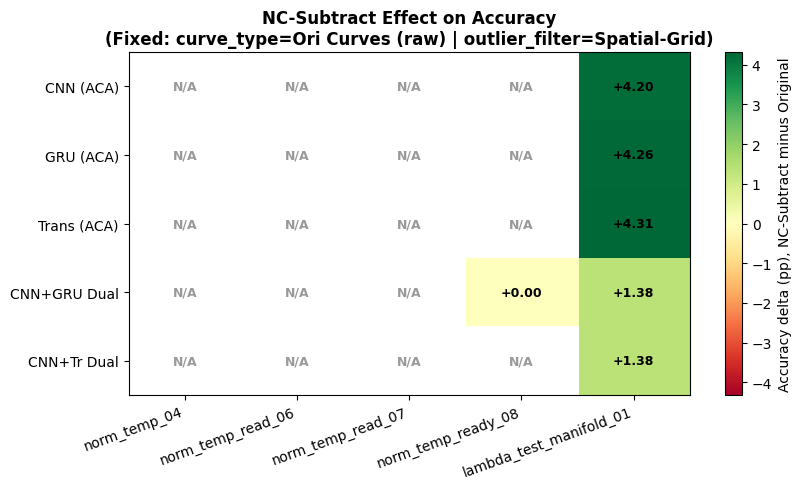

In [14]:
def plot_nc_subtract_delta_heatmap(df, curve_type="ori_curves", outlier_filter="spatial_grid_label_elbow"):
    key_cols = ["dataset", "model"]
    orig = df[(df.preprocessing == "original") & _eq(df.curve_type, curve_type) & _eq(df.outlier_filter, outlier_filter)].set_index(key_cols)["accuracy_mean"]
    ncs = df[(df.preprocessing == "nc_subtract") & _eq(df.curve_type, curve_type) & _eq(df.outlier_filter, outlier_filter)].set_index(key_cols)["accuracy_mean"]

    delta = (ncs - orig).reset_index()
    pivot = delta.pivot(index="model", columns="dataset", values="accuracy_mean").reindex(index=MODELS, columns=DATASET_NAMES)

    fig, ax = plt.subplots(figsize=(max(8, len(DATASET_NAMES) * 1.7), max(5, len(MODELS) * 0.65)))
    values = pivot.values.astype(float)
    bound = np.nanmax(np.abs(values)) if not np.all(np.isnan(values)) else 1
    im = ax.imshow(values, cmap="RdYlGn", vmin=-bound, vmax=bound, aspect="auto")

    for i in range(len(MODELS)):
        for j in range(len(DATASET_NAMES)):
            v = values[i, j]
            txt = f"{v:+.2f}" if not np.isnan(v) else "N/A"
            color = "#999999" if np.isnan(v) else "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9, fontweight="bold", color=color)

    ax.set_xticks(range(len(DATASET_NAMES)))
    ax.set_xticklabels(DATASET_NAMES, rotation=20, ha="right")
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels([MODEL_LABEL_MAP.get(m, m) for m in MODELS])
    plt.colorbar(im, ax=ax, label="Accuracy delta (pp), NC-Subtract minus Original")
    fixed = fixed_params_str(curve_type=curve_type, outlier_filter=outlier_filter)
    ax.set_title(f"NC-Subtract Effect on Accuracy\n(Fixed: {fixed})", fontweight="bold")
    fig.tight_layout()
    plt.show()
    return pivot


_delta_pivot = plot_nc_subtract_delta_heatmap(results_df)

## 13. Bonus insight: best configuration per dataset

For each dataset, the single (preprocessing, curve_type, outlier_filter, model) combo with
the highest accuracy -- a quick leaderboard rather than averages.

In [15]:
def best_config_per_dataset(df, restrict_preprocessing=None):
    sub = df if restrict_preprocessing is None else df[df.preprocessing == restrict_preprocessing]
    idx = sub.groupby("dataset")["accuracy_mean"].idxmax()
    cols = ["dataset", "preprocessing", "curve_type", "outlier_filter", "model", "accuracy_mean"]
    best = sub.loc[idx, cols].set_index("dataset").reindex(DATASET_NAMES)
    best["model"] = best["model"].map(MODEL_LABEL_MAP)
    best["outlier_filter"] = best["outlier_filter"].map(FILTER_LABEL_MAP)
    best["curve_type"] = best["curve_type"].map(CURVE_LABEL_MAP)
    return best.round(2)


print("Best overall configuration per dataset:")
display(best_config_per_dataset(results_df))

print("\nBest configuration per dataset, restricted to NC-Subtract:")
display(best_config_per_dataset(results_df, restrict_preprocessing="nc_subtract"))

Best overall configuration per dataset:


,preprocessing,curve_type,outlier_filter,model,accuracy_mean
dataset,,,,,
norm_temp_04,nc_subtract,Ori Curves (raw),None (Baseline),GRU (ACA),100.0
norm_temp_read_06,nc_subtract,Ori Curves (raw),LSTM-AE,CNN (ACA),100.0
norm_temp_read_07,nc_subtract,Ori Curves (raw),None (Baseline),GRU (ACA),100.0
norm_temp_ready_08,original,Ori Curves (raw),LSTM-AE,CNN (ACA),100.0
lambda_test_manifold_01,nc_subtract,Ori Curves (raw),Spatial-Grid,CNN+GRU Dual,99.6



Best configuration per dataset, restricted to NC-Subtract:


,preprocessing,curve_type,outlier_filter,model,accuracy_mean
dataset,,,,,
norm_temp_04,nc_subtract,Ori Curves (raw),None (Baseline),GRU (ACA),100.0
norm_temp_read_06,nc_subtract,Ori Curves (raw),LSTM-AE,CNN (ACA),100.0
norm_temp_read_07,nc_subtract,Ori Curves (raw),None (Baseline),GRU (ACA),100.0
norm_temp_ready_08,nc_subtract,Ori Curves (raw),LSTM-AE,CNN+GRU Dual,100.0
lambda_test_manifold_01,nc_subtract,Ori Curves (raw),Spatial-Grid,CNN+GRU Dual,99.6


## 14. Bonus insight: overall NC-Subtract impact summary

Paired difference (`nc_subtract - original`) across every (dataset, curve_type,
outlier_filter, model) combination present in *both* preprocessing variants -- a single
number for "does NC-subtract help, on average, across everything we've trained so far?

In [16]:
_key_cols = ["dataset", "curve_type", "outlier_filter", "model"]
_orig = results_df[results_df.preprocessing == "original"].set_index(_key_cols)["accuracy_mean"]
_ncs = results_df[results_df.preprocessing == "nc_subtract"].set_index(_key_cols)["accuracy_mean"]
_common = _orig.index.intersection(_ncs.index)
_diff = (_ncs.loc[_common] - _orig.loc[_common])

print(f"Paired combinations available: {len(_diff)}")
print(f"Mean accuracy delta (NC-Subtract - Original): {_diff.mean():+.3f} pp")
print(f"Share of combinations where NC-Subtract is better: {(_diff > 0).mean() * 100:.1f}%")
print()
print("Mean delta per dataset:")
display(_diff.groupby(level="dataset").mean().reindex(DATASET_NAMES).round(3).to_frame("mean_delta_pp"))

Paired combinations available: 48
Mean accuracy delta (NC-Subtract - Original): +2.688 pp
Share of combinations where NC-Subtract is better: 85.4%

Mean delta per dataset:


,mean_delta_pp
dataset,
norm_temp_04,NaN
norm_temp_read_06,NaN
norm_temp_read_07,NaN
norm_temp_ready_08,-0.033
lambda_test_manifold_01,3.232


## 15. Per-dataset comparison: pick any two variables for x-axis / sub-bars

Unlike sections 6-9 (which always put `dataset` on the x-axis), this plot is scoped to a
**single dataset** and lets you choose which of the remaining four dimensions
(`preprocessing`, `curve_type`, `outlier_filter`, `model`) goes on the x-axis and which
becomes the sub-bar grouping. The other two dimensions are held fixed (defaults shown,
overridable via keyword args).

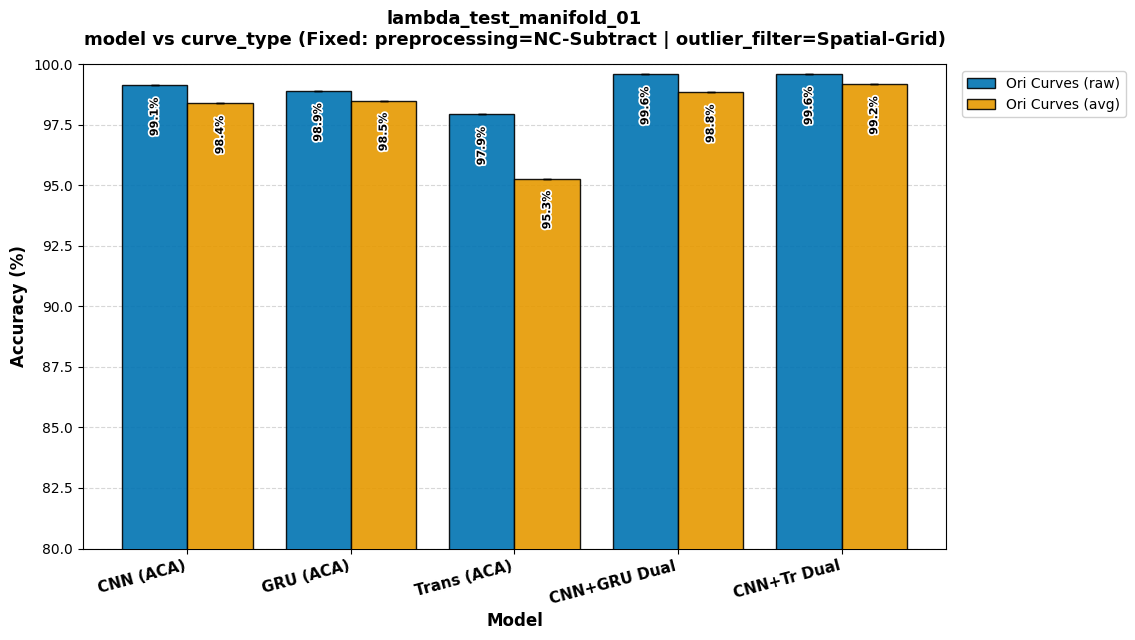

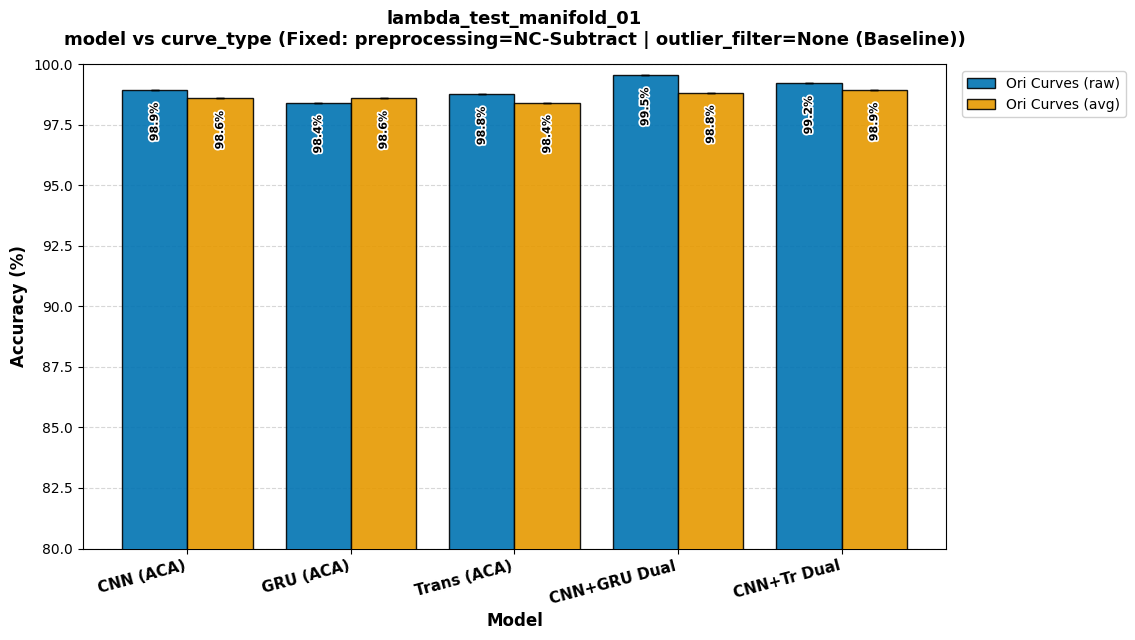

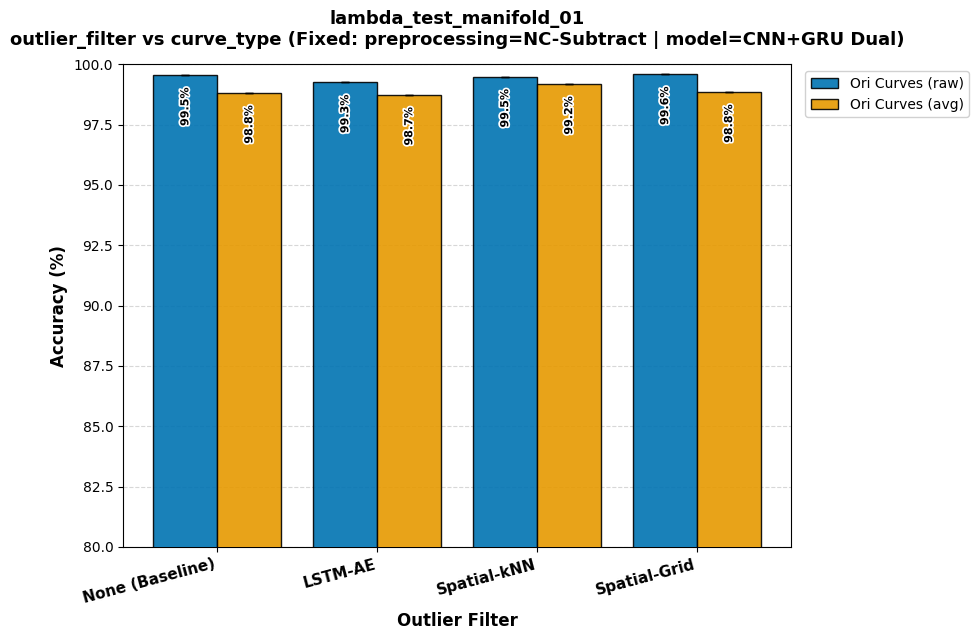

In [17]:
# Registry of the four non-dataset dimensions: order (for x/hue axis), colour map, label map.
DIM_REGISTRY = {
    "preprocessing": dict(order=PREPROCESSING_KEYS, color_map=PREP_COLOR_MAP, label_map=PREP_LABEL_MAP),
    "curve_type": dict(order=CURVE_TYPES, color_map=CURVE_COLOR_MAP, label_map=CURVE_LABEL_MAP),
    "outlier_filter": dict(order=OUTLIER_FILTERS, color_map=FILTER_COLOR_MAP, label_map=FILTER_LABEL_MAP),
    "model": dict(order=MODELS, color_map=MODEL_COLOR_MAP, label_map=MODEL_LABEL_MAP),
}

def plot_per_dataset_comparison(df, dataset_folder, dim_defaults,
                                  x_col="model", hue_col="outlier_filter", **fixed_overrides):
    """Single-dataset grouped bar chart: x=x_col, sub-bars=hue_col, y=accuracy_mean.

    The two dimensions not chosen as x_col/hue_col are held fixed at DIM_DEFAULTS,
    overridable via keyword args (e.g. preprocessing="original").
    """
    if x_col == hue_col:
        raise ValueError("x_col and hue_col must differ")
    if x_col not in DIM_REGISTRY or hue_col not in DIM_REGISTRY:
        raise ValueError(f"x_col/hue_col must be one of {list(DIM_REGISTRY)}")

    fixed_dims = [d for d in DIM_REGISTRY if d not in (x_col, hue_col)]
    unknown = set(fixed_overrides) - set(fixed_dims)
    if unknown:
        raise ValueError(f"Cannot override {unknown}: not fixed when x_col={x_col}, hue_col={hue_col}")
    fixed = {d: fixed_overrides.get(d, dim_defaults[d]) for d in fixed_dims}

    dataset = short_name(dataset_folder)
    sub = df[_eq(df.dataset, dataset)]
    for d, v in fixed.items():
        sub = sub[_eq(sub[d], v)]

    x_info, hue_info = DIM_REGISTRY[x_col], DIM_REGISTRY[hue_col]
    fixed_str = fixed_params_str(**fixed)
    grouped_bar_chart_generic(
        sub, x_col, x_info["order"], hue_col, hue_info["order"],
        hue_info["color_map"], hue_info["label_map"],
        title=f"{dataset}\n{x_col} vs {hue_col} (Fixed: {fixed_str})",
        x_label=x_col.replace("_", " ").title(),
        x_tick_label_map=x_info["label_map"],
    )



DEFAULT_DATASET_FOLDER = "D20260611_E00_C00_F4500KHz_U_lambda_test_manifold_01"

# DIM_DEFAULTS = {
#     "preprocessing": "nc_subtract",
#     "curve_type": "ori_curves",
#     "outlier_filter": "spatial_grid_label_elbow",
#     "model": "cnn_gru_dual",
# }
# plot_per_dataset_comparison(results_df, dim_defaults=DIM_DEFAULTS, dataset_folder=DEFAULT_DATASET_FOLDER, x_col="model",)



# #PREPROCESSING
# DEFAULT_VALUES_PREPROCESSING = {
#     # "preprocessing": "nc_subtract",
#     "curve_type": "ori_curves",
#     "outlier_filter": 'spatial_grid_label_elbow',
#     # "model": "cnn_gru_dual",
# }
# plot_per_dataset_comparison(results_df, dim_defaults=DEFAULT_VALUES_PREPROCESSING, dataset_folder=DEFAULT_DATASET_FOLDER, x_col="model", hue_col="preprocessing")

#CURVE TYPE
DEFAULT_VALUES_CURVE_TYPE = {
    "preprocessing": "nc_subtract",
    # "curve_type": "ori_curves",
    "outlier_filter": 'spatial_grid_label_elbow',
    # "model": "cnn_gru_dual",
}
plot_per_dataset_comparison(results_df, dim_defaults=DEFAULT_VALUES_CURVE_TYPE, dataset_folder=DEFAULT_DATASET_FOLDER, x_col="model", hue_col="curve_type")


#CURVE TYPE
DEFAULT_VALUES_CURVE_TYPE = {
    "preprocessing": "nc_subtract",
    # "curve_type": "ori_curves",
    "outlier_filter": None,
    # "model": "cnn_gru_dual",
}
plot_per_dataset_comparison(results_df, dim_defaults=DEFAULT_VALUES_CURVE_TYPE, dataset_folder=DEFAULT_DATASET_FOLDER, x_col="model", hue_col="curve_type")


# #OUTLIER
# DEFAULT_VALUES_OUTLIER_FILTER = {
#     "preprocessing": "nc_subtract",
#     "curve_type": "ori_curves",
#     "outlier_filter": 'spatial_grid_label_elbow',
#     # "model": "cnn_gru_dual",
# }
# plot_per_dataset_comparison(results_df, dim_defaults=DEFAULT_VALUES_OUTLIER_FILTER, dataset_folder=DEFAULT_DATASET_FOLDER, x_col="model", hue_col="outlier_filter")

#MODEL
DEFAULT_VALUES_MODEL = {
    "preprocessing": "nc_subtract",
    "curve_type": "ori_curves",
    "outlier_filter": 'spatial_grid_label_elbow',
    "model": "cnn_gru_dual",
}
plot_per_dataset_comparison(results_df, dim_defaults=DEFAULT_VALUES_MODEL, dataset_folder=DEFAULT_DATASET_FOLDER, x_col="outlier_filter", hue_col="curve_type")

In [18]:
results_df[results_df["dataset"] == "lambda_test_manifold_01"].sort_values(by="accuracy_mean", ascending=False).head(20)

,dataset,preprocessing,curve_type,outlier_filter,model,accuracy_mean,accuracy_std
202,lambda_test_manifold_01,nc_subtract,ori_curves,spatial_grid_label_elbow,cnn_trans_dual,99.597470,0.0
201,lambda_test_manifold_01,nc_subtract,ori_curves,spatial_grid_label_elbow,cnn_gru_dual,99.597470,0.0
186,lambda_test_manifold_01,nc_subtract,ori_curves,None,cnn_gru_dual,99.548023,0.0
196,lambda_test_manifold_01,nc_subtract,ori_curves,spatial_knn_label_elbow,cnn_gru_dual,99.483945,0.0
192,lambda_test_manifold_01,nc_subtract,ori_curves,lstm_ae_glb_ds1_label_elbow,cnn_trans_dual,99.307958,0.0
217,lambda_test_manifold_01,nc_subtract,ori_curves_avg,spatial_knn_label_elbow,cnn_trans_dual,99.250288,0.0
191,lambda_test_manifold_01,nc_subtract,ori_curves,lstm_ae_glb_ds1_label_elbow,cnn_gru_dual,99.250288,0.0
187,lambda_test_manifold_01,nc_subtract,ori_curves,None,cnn_trans_dual,99.209040,0.0
197,lambda_test_manifold_01,nc_subtract,ori_curves,spatial_knn_label_elbow,cnn_trans_dual,99.197248,0.0
222,lambda_test_manifold_01,nc_subtract,ori_curves_avg,spatial_grid_label_elbow,cnn_trans_dual,99.193548,0.0
